## FX portfolio

We want to monitor and manage the portfolio’s exposures to different risk factors, ensuring that the FX positions are aligned with our risk tolerance. The key exposures are:

- Currency Exposure: How much is invested in each currency.
- PnL Exposure: How much profit/loss is tied to FX moves.
- Delta Exposure: Sensitivity of portfolio value to FX rate changes
- VaR (Value-at-Risk): Potential loss due to FX volatility.
- Carry Exposure: Profit/loss from interest rate differentials.
- Correlation Exposure: Risk from correlations between currency pairs.

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Currency Exposure Calculation

Note that in the following calculations, the notional is the amount held in the base currency

In [3]:
# FX Portfolio Positions (Example)
positions = pd.DataFrame({
    "pair": ["EUR/USD", "GBP/USD", "USD/JPY", "AUD/USD"],
    "notional": [1_000_000, -500_000, 800_000, 600_000],  # Position sizes
    "fx_rate": [1.12, 1.30, 145.50, 0.65]  # Exchange rates
})

# Convert all positions to USD exposure
positions["usd_exposure"] = positions["notional"] * positions["fx_rate"]
positions["base_currency"] = positions["pair"].str[:3]  # Extract base currency

# Aggregate exposures per currency
currency_exposure = positions.groupby("base_currency")["usd_exposure"].sum()

print(currency_exposure)

base_currency
AUD       390000.0
EUR      1120000.0
GBP      -650000.0
USD    116400000.0
Name: usd_exposure, dtype: float64


In [4]:
positions

,pair,notional,fx_rate,usd_exposure,base_currency
0,EUR/USD,1000000,1.12,1120000.0,EUR
1,GBP/USD,-500000,1.30,-650000.0,GBP
2,USD/JPY,800000,145.50,116400000.0,USD
3,AUD/USD,600000,0.65,390000.0,AUD


## 2. Delta Exposure: Sensitivity to FX Moves

Delta measures how much the USD value of the portfolio changes if an FX rate moves by 1%.

In [5]:
# Compute Delta Exposure (1% FX move impact)
positions["delta_exposure"] = positions["usd_exposure"] * 0.01

# Display results
print(positions[["pair", "usd_exposure", "delta_exposure"]])

      pair  usd_exposure  delta_exposure
0  EUR/USD     1120000.0         11200.0
1  GBP/USD     -650000.0         -6500.0
2  USD/JPY   116400000.0       1164000.0
3  AUD/USD      390000.0          3900.0


## 3. Value-at-Risk (VaR) for FX Portfolio

In [8]:
# Historical FX returns (example simulated data)
fx_returns = {
    "EUR/USD": np.random.normal(0, 0.005, 1000),  # 0.5% daily volatility
    "GBP/USD": np.random.normal(0, 0.007, 1000),  # 0.7% daily volatility
    "USD/JPY": np.random.normal(0, 0.004, 1000),
    "AUD/USD": np.random.normal(0, 0.006, 1000)
}

# Compute portfolio return distribution
portfolio_returns = sum(positions.loc[i, "usd_exposure"] * fx_returns[positions.loc[i, "pair"]]
                        for i in range(len(positions))) / sum(positions["usd_exposure"])

# Compute 95% VaR (5th percentile loss)
var_95 = np.percentile(portfolio_returns, 5)

print(f"95% Value-at-Risk: ${var_95:,.2f}")

95% Value-at-Risk: $-0.01


## 4. Carry Trade Exposure

A carry trade earns profit from interest rate differentials. If we hold a long position in a high-yielding currency (e.g., AUD) and short a low-yielding one (e.g., JPY), we earn the interest rate difference.

In [12]:
# Interest rates (example data)
interest_rates = {
    "EUR": -0.5,
    "GBP": 1.0,
    "USD": 3.0,
    "JPY": -0.1,
    "AUD": 4.0
}

# Compute Carry Exposure
positions["carry_exposure"] = positions.apply(
    lambda row: (interest_rates[row["base_currency"]] - interest_rates["USD"]) * row["notional"] / 100, axis=1
)

print(positions[["pair", "carry_exposure"]])

      pair  carry_exposure
0  EUR/USD        -35000.0
1  GBP/USD         10000.0
2  USD/JPY             0.0
3  AUD/USD          6000.0


## 5. Correlation Risk Exposure

Some currency pairs are highly correlated, which increases risk concentration.
- High correlation → Hedging one currency pair with another won’t work.
- Low correlation → Portfolio diversification benefits.

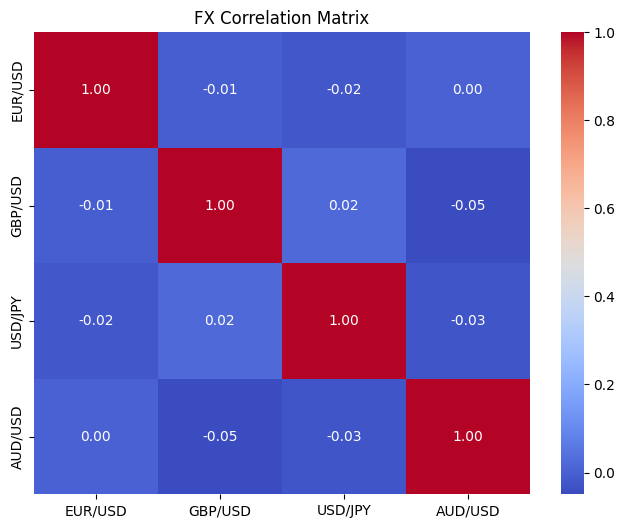

In [14]:
# Simulated historical returns for FX pairs
returns_df = pd.DataFrame(fx_returns)

# Compute correlation matrix
correlation_matrix = returns_df.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("FX Correlation Matrix")
plt.show()

## 6. FX Portfolio PnL Calculation

In [15]:
# Simulated FX rate changes (1% random move)
positions["fx_move"] = np.random.uniform(-0.01, 0.01, len(positions))

# Compute daily PnL
positions["pnl"] = positions["usd_exposure"] * positions["fx_move"]

print(positions[["pair", "fx_move", "pnl"]])

      pair   fx_move           pnl
0  EUR/USD  0.003106  3.478676e+03
1  GBP/USD -0.007038  4.574817e+03
2  USD/JPY -0.008822 -1.026886e+06
3  AUD/USD -0.002127 -8.296285e+02
